**Assignment no.2:  Analysis of Variance**

**Lab Experiment 1 using python
Generate three independent samples randomly and perform One-way ANOVA f_oneway
function and calculate p-value. Interpret if the null hypothesis will be rejected or accepted
based on the p-values.**

In [1]:
# One-Way ANOVA using Python

from numpy.random import seed
from numpy.random import randn
from scipy.stats import f_oneway

# Seed the random number generator
seed(1)

# Generate three independent samples
data1 = randn(100) + 50
data2 = randn(100) + 55
data3 = randn(100) + 60

# Perform One-Way ANOVA
stat, p = f_oneway(data1, data2, data3)

# Print results
print('F-Statistic = %.3f, p-value = %.3f' % (stat, p))

# Level of significance
alpha = 0.05

# Interpretation
if p > alpha:
    print('Fail to Reject H0')
    print('All sample means are equal')
else:
    print('Reject H0')
    print('At least one sample mean is different')

F-Statistic = 2761.512, p-value = 0.000
Reject H0
At least one sample mean is different


**Lab Experiment 2 using python
Perform one way anova for the following 3 groups. Also perform tuckeyhsd test to
determine if the difference between means is significant for some groups at 5% los.
data1 - 21,22,23,25.27,34,55,74,73,45
data2 - 23,42,55,26,26,45,48,44,67,71
data3 - 23,42,51,21,24,46,48,44,67,71**

In [3]:
#analysis of variance test
from numpy.random import seed
from numpy.random import randn
from scipy.stats import f_oneway
# seed the random number generator
seed(1)
# generate three independent samples
data1 =  [21,22,23,25.27,34,55,74,73,45]
data2 = [23,42,55,26,26,45,48,44,67,71]
data3 = [23,42,51,21,24,46,48,44,67,71]
# compare samples
stat, p = f_oneway(data1, data2, data3)
print('Statistics=%.3f, p=%.3f' % (stat, p))
# interpret
alpha = 0.05
if p > alpha:
    print('Same distributions -fail to reject H0')
else:
    print('Different distributions- reject H0')


Statistics=0.080, p=0.923
Same distributions -fail to reject H0


**Lab Experiment 3 using python
Perform one way anova for the following 3 groups. Also perform tuckeyhsd test to
determine if the difference between means is significant for some groups at 5% los.
group 0 - 24.5, 23.5, 26.4, 27.1, 29.9
group 1 - 28.4, 34.2, 29.5, 32.2, 30.1
group 2 - 26.1, 28.3, 24.3, 26.2, 27.8**

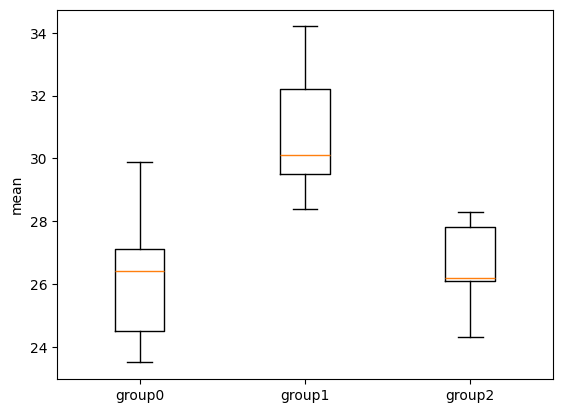

In [4]:
import numpy as np
from scipy.stats import tukey_hsd
group0 = [24.5, 23.5, 26.4, 27.1, 29.9]
group1 = [28.4, 34.2, 29.5, 32.2, 30.1]
group2 = [26.1, 28.3, 24.3, 26.2, 27.8]
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 1)
ax.boxplot([group0, group1, group2])
ax.set_xticklabels(["group0", "group1", "group2"])
ax.set_ylabel("mean")
plt.show()

**One Way Anova and Post-hoc test (Tuckey HSD)
Lab Experiment 4 using python
Perform one way anova for the following 3 groups. Also perform tuckeyhsd test to
determine if the difference between means is significant for some groups at 5% los.
Perform Tuckey HSD test to test signifance of difference between means with each group
pairs.
group a - 85, 86, 88, 75, 78, 94, 98, 79, 71, 80
group b - 91, 92, 93, 90, 97, 94, 82, 88, 95, 96
group c - 79, 78, 88, 94, 92, 85, 83, 85, 82, 81**

In [11]:
import pandas as pd
import numpy as np
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [12]:
#enter data for three groups
a = [85, 86, 88, 75, 78, 94, 98, 79, 71, 80]
b = [91, 92, 93, 90, 97, 94, 82, 88, 95, 96]
c = [79, 78, 88, 94, 92, 85, 83, 85, 82, 81]
#perform one-way ANOVA
f_oneway(a, b, c)

F_onewayResult(statistic=np.float64(5.167774552944483), pvalue=np.float64(0.012582197136592583))

We can see that the overall p-value from the ANOVA table is 0.01258.
Since this is less than .05, we have sufficient evidence to say that the mean values across each group are not equal.
Thus, we can proceed to perform Tukey’s Test to determine exactly which group means are different. To perform Tukey’s test in Python,
we can use the pairwise_tukeyhsd() function from the statsmodels library:

In [13]:
#create DataFrame to hold data
df = pd.DataFrame({'score': [85, 86, 88, 75, 78, 94, 98, 79, 71, 80,
91, 92, 93, 90, 97, 94, 82, 88, 95, 96,
79, 78, 88, 94, 92, 85, 83, 85, 82, 81],
'group': np.repeat(['a', 'b', 'c'], repeats=10)})
# perform Tukey's test
tukey = pairwise_tukeyhsd(endog=df['score'],
groups=df['group'],
alpha=0.05)
#display results
print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     a      b      8.4 0.0159   1.4259 15.3741   True
     a      c      1.3 0.8894  -5.6741  8.2741  False
     b      c     -7.1 0.0454 -14.0741 -0.1259   True
-----------------------------------------------------


**Interpretation of the output:
P-value for the difference in means between a and b: .0159 P-value for the difference in means between a and c: .8864 P-value for the
difference in means between b and c: .0454 Thus, we would conclude that there is a statistically significant difference between the means
of groups a and b and groups b and c, but not a statistically significant difference between the means of groups a and c.**

**Lab Experiment 5 using python
Perform 2-Way ANOVA on the shared dataset on two categories A and B and their
values: Two_Way_Anova_Dataset. Print the output in terms of 1. Degree of freedom for
residues as "df["Err"]", 2. Mean Square Error for residues as "ms["Err"]",
3. Anova for rows as Fischer's value "F1",
4. Anova for columns as Fischer's value "F2"
and interpret your results.
Cat A A A A A B B B B A A A A C C C C B B B
Cat B R S T T S R S R U U R R S S T S T S R
Value 1.0 1.0 1.0 1.0 2.0 2.0 2.0 2.0 1.0 1.0 1.0 1.0 3.0 3.0 3.0 3.0 2.0 2.00**

In [7]:
import pandas as pd
from statsmodels.formula.api import ols
from statsmodels.api import stats

# Provided data
cat_a_str = "A A A A A B B B B A A A A C C C C B B B"
cat_b_str = "R S T T S R S R U U R R S S T S T S R"
value_str = "1.0 1.0 1.0 1.0 2.0 2.0 2.0 2.0 1.0 1.0 1.0 1.0 3.0 3.0 3.0 3.0 2.0 2.00"

cat_a = cat_a_str.split()
cat_b = cat_b_str.split()
values = [float(v) for v in value_str.split()]

# Ensure all lists have the same length due to potential prompt inconsistencies
min_len = min(len(cat_a), len(cat_b), len(values))
cat_a = cat_a[:min_len]
cat_b = cat_b[:min_len]
values = values[:min_len]

# Create a DataFrame
df_anova = pd.DataFrame({
    'CategoryA': cat_a,
    'CategoryB': cat_b,
    'Value': values
})

print("DataFrame for 2-Way ANOVA:")
display(df_anova.head())


DataFrame for 2-Way ANOVA:


,CategoryA,CategoryB,Value
0,A,R,1.0
1,A,S,1.0
2,A,T,1.0
3,A,T,1.0
4,A,S,2.0


In [10]:
# Perform Two-Way ANOVA
# The formula 'Value ~ C(CategoryA) + C(CategoryB) + C(CategoryA):C(CategoryB)'
# accounts for main effects of CategoryA and CategoryB, and their interaction.
model = ols('Value ~ C(CategoryA) + C(CategoryB) + C(CategoryA):C(CategoryB)', data=df_anova).fit()
anova_table = stats.anova_lm(model, typ=2)

print("ANOVA Table:")
print(anova_table)

# Extract and print the requested values
# 1. Degree of freedom for residues as "df["Err"]"
df_err = anova_table.loc['Residual', 'df']
print(f"\n1. Degree of freedom for residues (df[\"Err\"]): {df_err}")

# 2. Mean Square Error for residues as "ms["Err"]"
ms_err = anova_table.loc['Residual', 'sum_sq'] / anova_table.loc['Residual', 'df']
print(f"2. Mean Square Error for residues (ms[\"Err\"]): {ms_err}")

# 3. Anova for rows as Fischer's value "F1" (for CategoryA)
f1 = anova_table.loc['C(CategoryA)', 'F']
print(f"3. Anova for rows (CategoryA) as Fischer's value (F1): {f1}")

# 4. Anova for columns as Fischer's value "F2" (for CategoryB)
f2 = anova_table.loc['C(CategoryB)', 'F']
print(f"4. Anova for columns (CategoryB) as Fischer's value (F2): {f2}")

# Interpretation
alpha = 0.05
print("\nInterpretation of Results:")

# Main effect of CategoryA
p_cat_a = anova_table.loc['C(CategoryA)', 'PR(>F)']
if p_cat_a < alpha:
    print(f"- Main effect of CategoryA is significant (p={p_cat_a:.3f} < {alpha}).")
else:
    print(f"- Main effect of CategoryA is not significant (p={p_cat_a:.3f} > {alpha}).")

# Main effect of CategoryB
p_cat_b = anova_table.loc['C(CategoryB)', 'PR(>F)']
if p_cat_b < alpha:
    print(f"- Main effect of CategoryB is significant (p={p_cat_b:.3f} < {alpha}).")
else:
    print(f"- Main effect of CategoryB is not significant (p={p_cat_b:.3f} > {alpha}).")

# Interaction effect
p_interaction = anova_table.loc['C(CategoryA):C(CategoryB)', 'PR(>F)']
if p_interaction < alpha:
    print(f"- Interaction effect between CategoryA and CategoryB is significant (p={p_interaction:.3f} < {alpha}).")
else:
    print(f"- Interaction effect between CategoryA and CategoryB is not significant (p={p_interaction:.3f} > {alpha}).")


ANOVA Table:
                             sum_sq   df         F    PR(>F)
C(CategoryA)               0.252577  2.0  0.454638  0.517083
C(CategoryB)               2.863629  3.0  3.436355  0.077833
C(CategoryA):C(CategoryB)  7.128425  6.0  4.277055  0.032738
Residual                   2.500000  9.0       NaN       NaN

1. Degree of freedom for residues (df["Err"]): 9.0
2. Mean Square Error for residues (ms["Err"]): 0.27777777777777773
3. Anova for rows (CategoryA) as Fischer's value (F1): 0.4546379647749953
4. Anova for columns (CategoryB) as Fischer's value (F2): 3.436354724808491

Interpretation of Results:
- Main effect of CategoryA is not significant (p=0.517 > 0.05).
- Main effect of CategoryB is not significant (p=0.078 > 0.05).
- Interaction effect between CategoryA and CategoryB is significant (p=0.033 < 0.05).


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 2, but rank is 1
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 3, but rank is 2
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 6, but rank is 4
  warnings.warn('covariance of constraints does not have full '
